## **Exploratory Data Analysis (EDA)**

### Import libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [8]:
# Load Data

df = pd.read_csv("..\data\processed\MAYBANK_preprocessed.csv", parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.head()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\lunwe\AppData\Local\Temp\ipykernel_24116\1823944016.py:3: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("..\data\processed\MAYBANK_preprocessed.csv", parse_dates=['Date'])


,Open,High,Low,Close,Volume,Return,MA5,MA10,Volatility,Target
Date,,,,,,,,,,
2024-09-09,10.176235,10.365033,10.100715,10.289514,20533500,0.009259,10.195115,10.174347,0.006523,1
2024-09-10,10.346153,10.421672,10.289513,10.327272,35524000,0.003670,10.240426,10.197002,0.004672,1
2024-09-11,10.375758,10.492121,10.278789,10.356364,26690300,0.002817,10.272676,10.207463,0.003793,0
2024-09-12,10.356364,10.453333,10.278789,10.317576,25908500,-0.003745,10.297168,10.231037,0.004805,0
2024-09-13,10.317576,10.336970,10.259394,10.317576,16938300,0.000000,10.321661,10.245172,0.004805,1


### Data Describe

In [15]:
df.tail(5)

,Open,High,Low,Close,Volume,Return,MA5,MA10,Volatility,Target
Date,,,,,,,,,,
2025-08-21,9.81,9.85,9.78,9.78,15263300,-0.002041,9.792,9.763,0.002323,1
2025-08-22,9.81,9.88,9.80,9.80,20549800,0.002045,9.792,9.782,0.002043,1
2025-08-25,9.85,9.90,9.83,9.85,17724500,0.005102,9.806,9.802,0.002661,0
2025-08-26,9.85,9.88,9.75,9.75,81816700,-0.010152,9.796,9.806,0.005752,1
2025-08-27,9.78,9.83,9.72,9.79,7930800,0.004103,9.794,9.799,0.006207,0


In [16]:
# Data Basic Info

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 239 entries, 2024-09-09 to 2025-08-27
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Open        239 non-null    float64
 1   High        239 non-null    float64
 2   Low         239 non-null    float64
 3   Close       239 non-null    float64
 4   Volume      239 non-null    int64  
 5   Return      239 non-null    float64
 6   MA5         239 non-null    float64
 7   MA10        239 non-null    float64
 8   Volatility  239 non-null    float64
 9   Target      239 non-null    int64  
dtypes: float64(8), int64(2)
memory usage: 20.5 KB
None
             Open        High         Low       Close        Volume  \
count  239.000000  239.000000  239.000000  239.000000  2.390000e+02   
mean     9.973510   10.026340    9.918225    9.966709  1.145492e+07   
std      0.240510    0.244710    0.236210    0.246371  7.451492e+06   
min      9.410000    9.490000    9.320000   

### Trend Plot

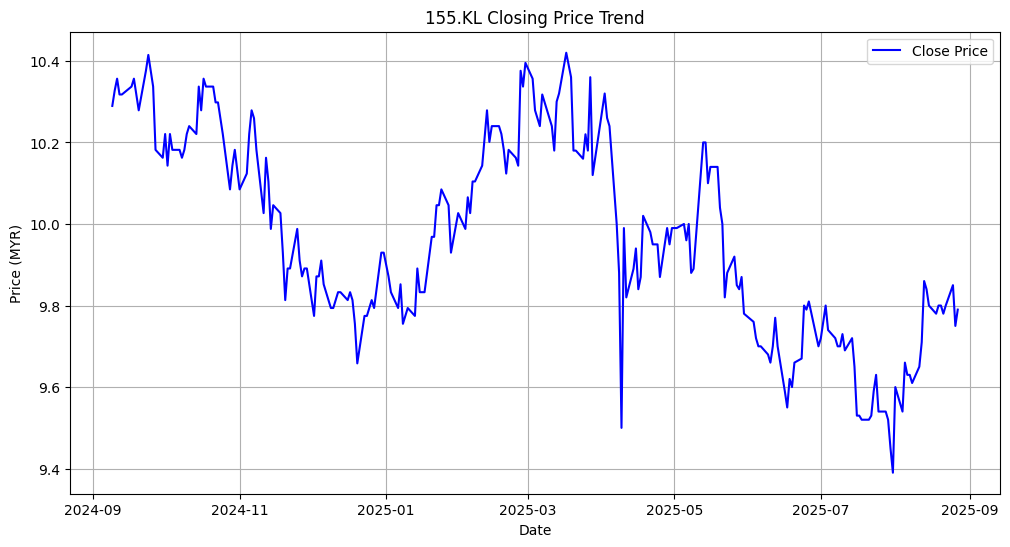

In [17]:
# Closing Price Trend

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.title('155.KL Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price (MYR)')
plt.legend()
plt.grid()
plt.show()

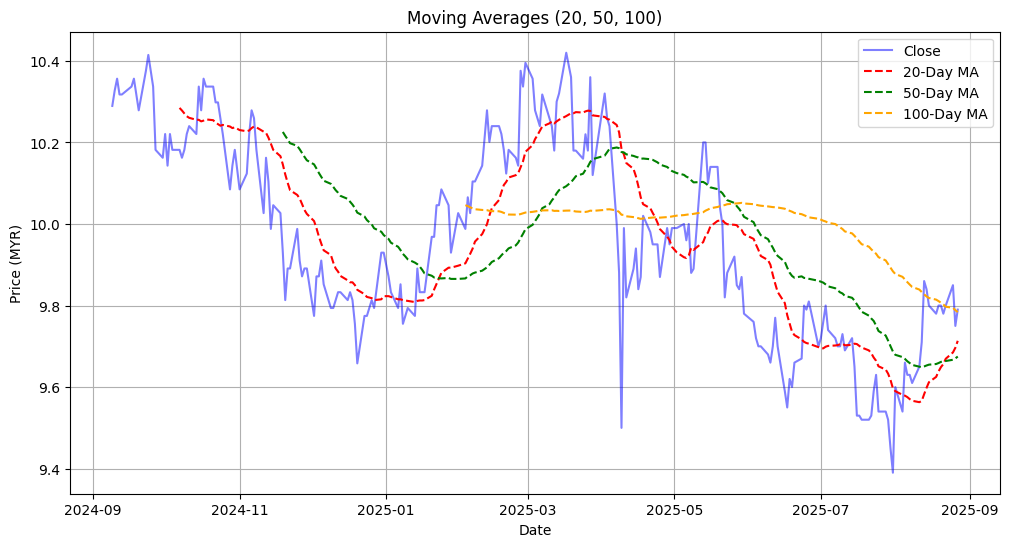

In [22]:
# Moving Average

df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA100'] = df['Close'].rolling(window=100).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close', color='blue', alpha=0.5)
plt.plot(df['MA20'], label='20-Day MA', color='red', linestyle='--')
plt.plot(df['MA50'], label='50-Day MA', color='green', linestyle='--')
plt.plot(df['MA100'], label='100-Day MA', color='orange', linestyle='--')
plt.title('Moving Averages (20, 50, 100)')
plt.xlabel('Date')
plt.ylabel('Price (MYR)')
plt.legend()
plt.grid()
plt.show()

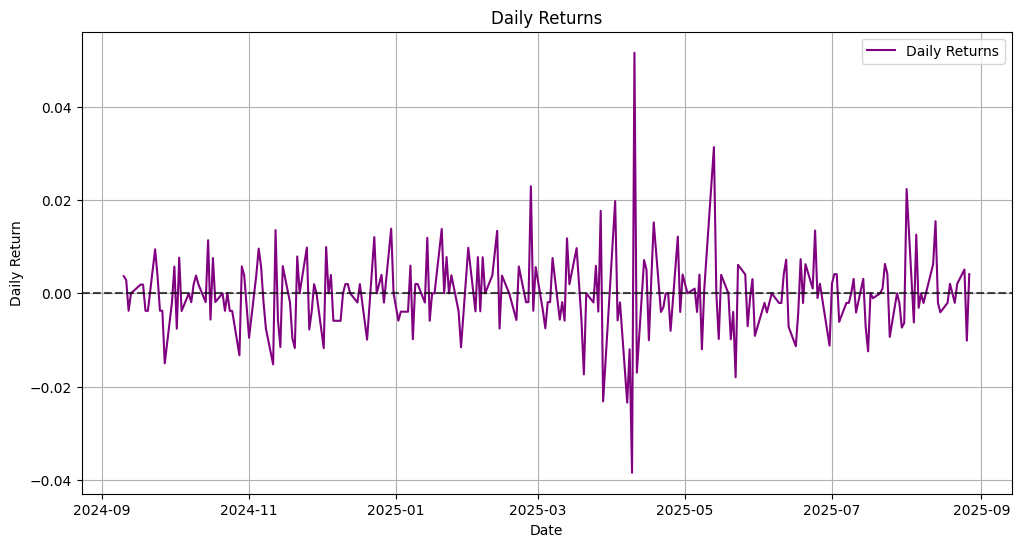

In [23]:
# Daily Returns

df['Daily_Return'] = df['Close'].pct_change()
plt.figure(figsize=(12,6))
plt.plot(df['Daily_Return'], label='Daily Returns', color='purple')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.grid()
plt.show()

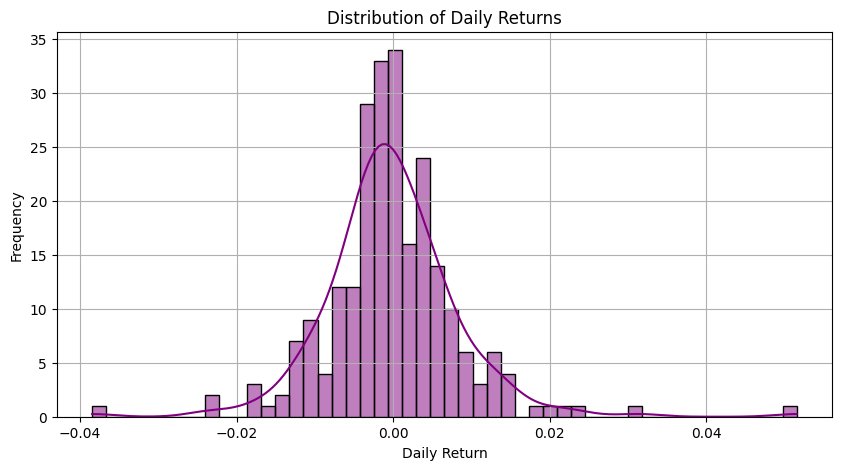

In [24]:
# --- 7. Histogram of Daily Returns ---
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid()
plt.show()

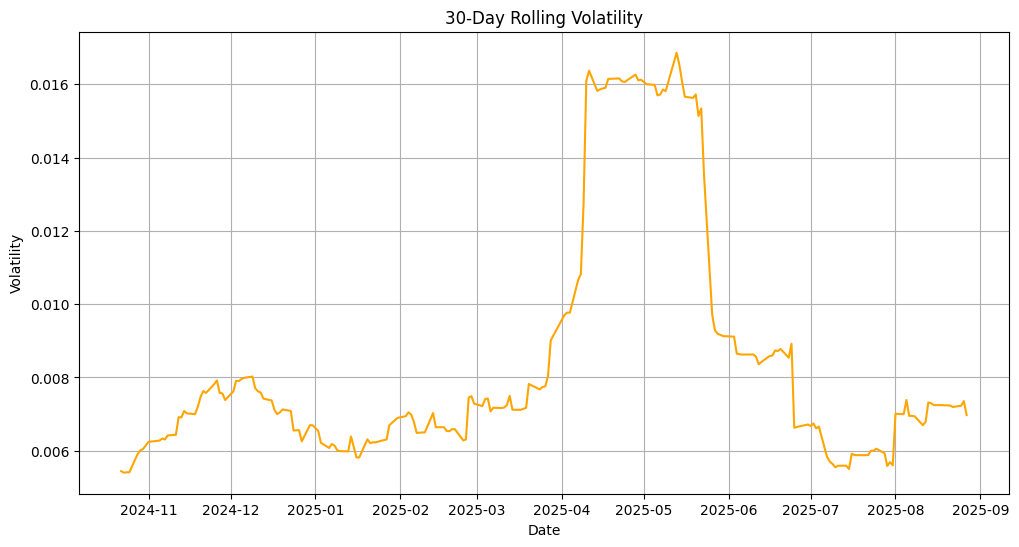

In [25]:
# --- 8. Rolling Volatility ---
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()
plt.figure(figsize=(12,6))
plt.plot(df['Volatility_30d'], color='orange')
plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid()
plt.show()

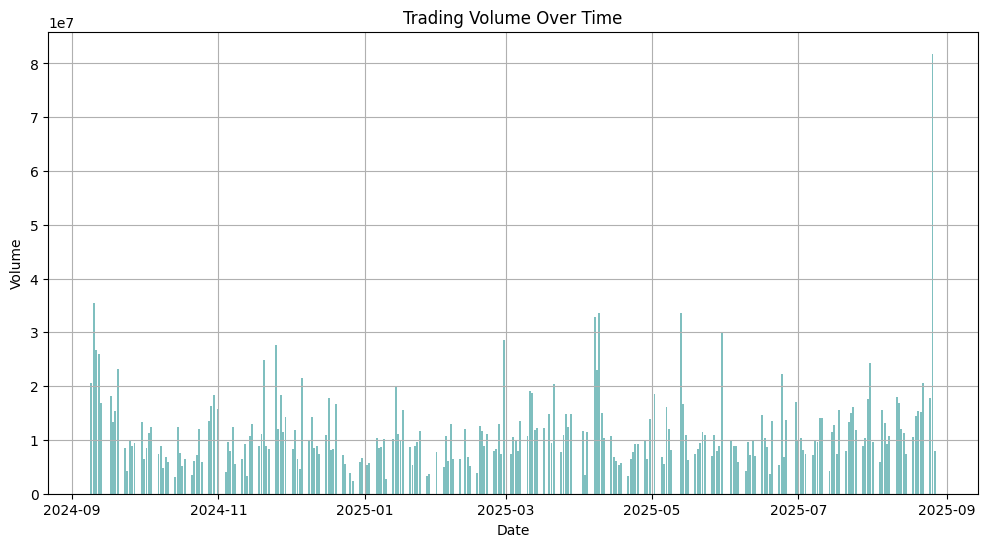

In [27]:
# --- 9. Trading Volume ---
if 'Volume' in df.columns:
    plt.figure(figsize=(12,6))
    plt.bar(df.index, df['Volume'], color='teal', alpha=0.5)
    plt.title('Trading Volume Over Time')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.grid()
    plt.show()

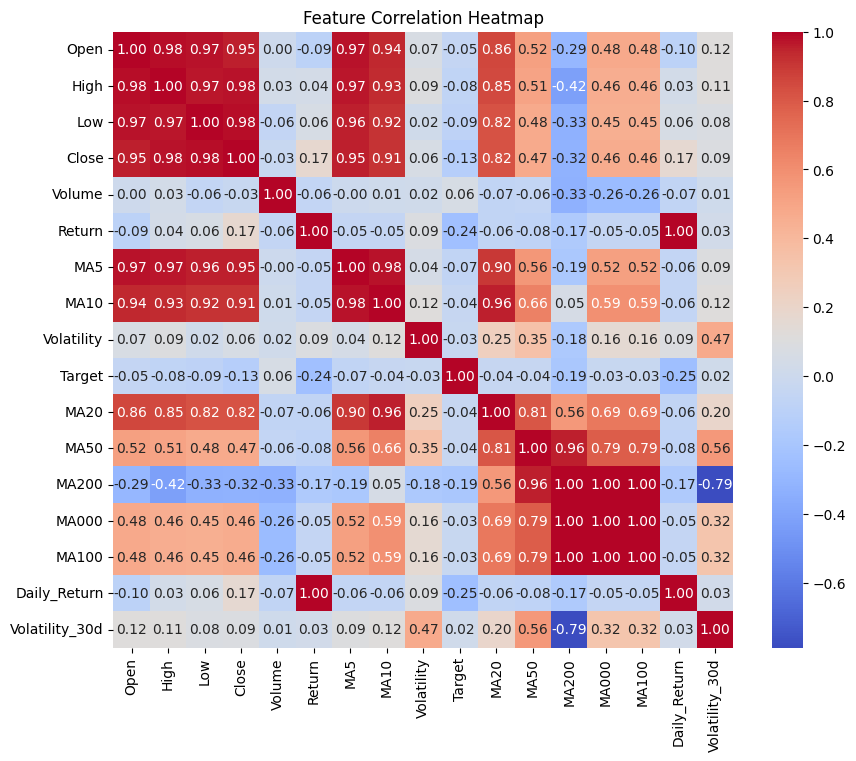

In [28]:
# --- 10. Correlation Heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

C:\Users\lunwe\AppData\Local\Temp\ipykernel_24116\2780685625.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = df['Daily_Return'].resample('M').mean()


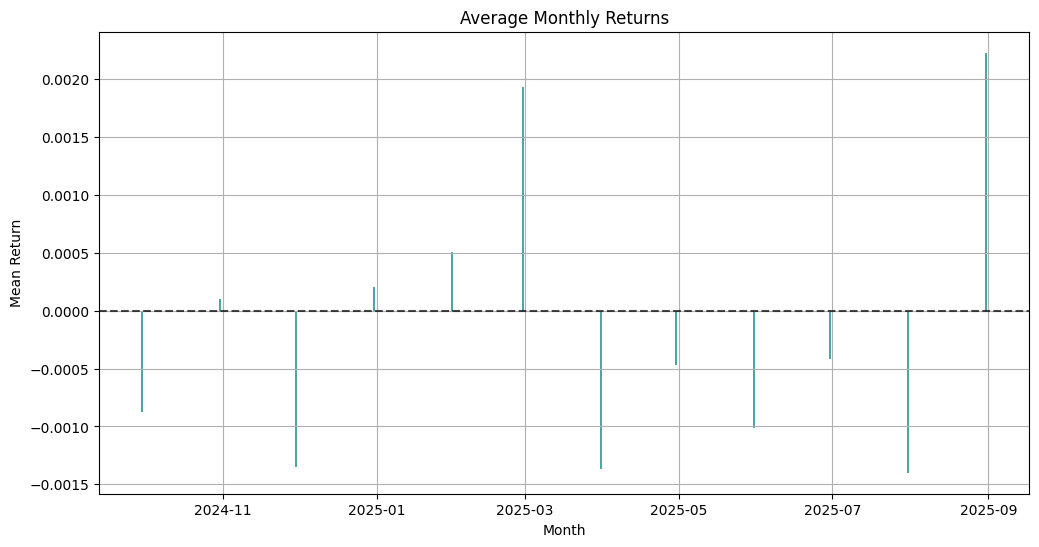

In [29]:
# --- 11. Monthly Returns ---
monthly_returns = df['Daily_Return'].resample('M').mean()
plt.figure(figsize=(12,6))
plt.bar(monthly_returns.index, monthly_returns, color='teal', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Average Monthly Returns')
plt.xlabel('Month')
plt.ylabel('Mean Return')
plt.grid()
plt.show()

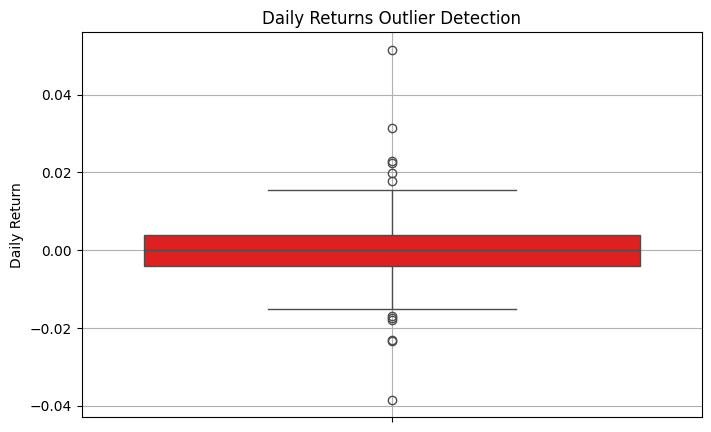

In [30]:
# --- 12. Outlier Detection (Boxplot) ---
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Daily_Return'], color='red')
plt.title('Daily Returns Outlier Detection')
plt.ylabel('Daily Return')
plt.grid()
plt.show()

In [31]:
# --- 13. Key Metrics ---
mean_daily_return = df['Daily_Return'].mean()
std_daily_return = df['Daily_Return'].std()
annual_volatility = std_daily_return * np.sqrt(252)

print(f"Mean Daily Return: {mean_daily_return:.4f}")
print(f"Standard Deviation of Daily Returns: {std_daily_return:.4f}")
print(f"Annualized Volatility: {annual_volatility:.4f}")

Mean Daily Return: -0.0002
Standard Deviation of Daily Returns: 0.0086
Annualized Volatility: 0.1367
